In [3]:
import pandas as pd 
import numpy as np


<h1>#1 Wczytywanie danych</h1> <br>
Ten zbiór danych zawiera różne dokumenty finansowe, metryki, dane cen (akcji) - to jest jeden z 11 plików csv, zawierających konkretne dane finansowe

In [4]:
data = pd.read_csv("./dataset/dataset/Annual_P_L_1_final.csv")
df = pd.DataFrame(data)
df

,Name,BSE Code,NSE Code,Industry,Current Price,Sales,OPM,Profit after tax,Return on capital employed,EPS,...,Extraordinary items preceding year,Net Profit preceding year,Dividend preceding year,OPM preceding year,NPM preceding year,EPS preceding year,Sales preceding 12months,Net profit preceding 12months,Market Capitalization,join_key
0,20 Microns,533022.0,20MICRONS,Mining / Minerals / Metals,224.55,777.49,13.59,57.38,21.70,15.89,...,0.00,41.96,2.65,12.23,5.98,11.85,738.43,51.80,792.37,533022.0_20MICRONS
1,21st Cent. Mgmt.,526921.0,21STCENMGM,Finance & Investments,70.44,34.92,94.27,32.23,73.00,30.70,...,0.00,-15.58,0.00,-115.06,NaN,-14.84,11.94,9.93,73.96,526921.0_21STCENMGM
2,360 ONE,542772.0,360ONE,Finance & Investments,1009.40,2920.91,58.37,804.18,14.47,22.41,...,0.01,657.89,2457.09,62.77,31.99,18.48,2245.61,717.01,36627.84,542772.0_360ONE
3,3B Blackbio,532067.0,__NA__,Healthcare,1182.00,74.12,44.50,32.10,20.95,38.13,...,0.00,25.94,1.87,47.12,41.95,34.55,69.24,28.49,1014.49,532067.0___NA__
4,3C IT Solutions,544190.0,__NA__,Computers - Software - Medium / Small,44.01,61.93,5.17,1.14,25.63,31.67,...,0.00,1.11,0.00,4.21,1.66,1110.00,NaN,NaN,26.50,544190.0___NA__
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4663,Zota Health Care,-1.0,ZOTA,Trading,571.75,180.49,4.18,-14.35,-7.32,-5.55,...,0.54,-5.77,2.52,5.27,-4.53,-2.29,167.70,-10.06,1516.67,-1.0_ZOTA
4664,Zuari Agro Chem.,534742.0,ZUARI,Fertilizers,227.50,4595.46,7.75,99.81,11.13,23.73,...,478.77,539.04,0.00,7.39,3.09,113.33,5036.70,-333.13,956.82,534742.0_ZUARI
4665,Zuari Industries,500780.0,ZUARIIND,Sugar,398.00,837.80,6.19,-0.71,4.90,239.72,...,6.18,305.13,2.98,2.91,31.32,102.85,857.56,749.52,1185.28,500780.0_ZUARIIND
4666,Zydus Lifesci.,532321.0,ZYDUSLIFE,Pharmaceuticals - Indian - Bulk Drugs & Formln,1070.05,19547.40,27.54,3855.24,22.40,38.36,...,-588.00,2091.90,607.20,22.39,14.62,19.37,19024.20,3084.90,107672.10,532321.0_ZYDUSLIFE


<h1>#2 Katalogowanie danych na konkretne sektor finansowy</h1>


In [5]:
industry_df = df['Industry']
industry_list = []
for industry in industry_df:
    if industry not in industry_list:
        industry_list.append(industry)

print(industry_list)
print(len(industry_list))

['Mining / Minerals / Metals', 'Finance & Investments', 'Healthcare', 'Computers - Software - Medium / Small', 'Diversified - Large', 'Entertainment / Electronic Media Software', 'Trading', 'Electric Equipment', 'Construction', 'Textiles - Processing', 'Engineering - Turnkey Services', 'Finance - Housing', 'Plastics Products', 'Oil Drilling / Allied Services', 'Steel - Medium / Small', 'Pharmaceuticals - Indian - Bulk Drugs', 'Textiles - Products', 'Engineering', 'Chemicals', 'Pharmaceuticals - Indian - Bulk Drugs & Formln', 'Textiles - Cotton/Blended', 'Miscellaneous', 'Pharmaceuticals - Multinational', 'Shipping', 'Cement - North India', 'Telecommunications - Service Provider', 'Diversified - Medium / Small', 'Power Generation And Supply', 'Solvent Extraction', 'Packaging', 'Telecommunications - Equipment', 'Food - Processing - Indian', 'Textiles - Spinning - Synthetic / Blended', 'Pharmaceuticals - Indian - Formulations', 'Electrodes - Welding Equipment', 'Personal Care - Indian', '

In [6]:
df_fi = df.copy().where(df['Industry'] == 'Finance & Investments').dropna() # finance and investemnts
df_fi = df_fi.drop('Industry', axis=1)
df_fi

,Name,BSE Code,NSE Code,Current Price,Sales,OPM,Profit after tax,Return on capital employed,EPS,Change in promoter holding,...,Extraordinary items preceding year,Net Profit preceding year,Dividend preceding year,OPM preceding year,NPM preceding year,EPS preceding year,Sales preceding 12months,Net profit preceding 12months,Market Capitalization,join_key
2,360 ONE,542772.0,360ONE,1009.40,2920.91,58.37,804.18,14.47,22.41,-0.01,...,0.01,657.89,2457.09,62.77,31.99,18.48,2245.61,717.01,36627.84,542772.0_360ONE
7,3P Land Hold.,516092.0,3PLAND,38.18,3.56,70.51,1.81,2.94,1.01,0.00,...,0.00,1.54,0.00,84.92,61.11,0.86,3.14,1.72,68.73,516092.0_3PLAND
9,5Paisa Capital,540776.0,5PAISA,515.15,394.57,27.90,54.44,13.35,17.45,-0.04,...,0.00,43.57,0.00,25.59,12.88,14.22,372.30,63.08,1607.41,540776.0_5PAISA
19,A R C Finance,540135.0,__NA__,1.17,9.24,7.14,0.27,0.69,0.01,0.00,...,0.00,0.33,0.00,26.45,4.77,0.01,5.97,-0.23,59.10,540135.0___NA__
21,A.K.Capital Serv,530499.0,__NA__,1054.00,518.54,62.97,91.71,9.46,138.95,0.00,...,0.00,88.41,7.92,63.00,21.75,132.77,488.74,87.08,695.64,530499.0___NA__
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4587,Williamson Fin.,519214.0,__NA__,7.40,2.12,-401.89,-4.72,-3.77,-5.65,0.00,...,0.00,-18.51,0.00,-749.45,-511.33,-22.14,5.70,-21.89,6.19,519214.0___NA__
4588,Williamson Magor,519224.0,WILLAMAGOR,37.53,2.89,-1357.79,-50.42,-7.39,-46.02,0.00,...,52.23,17.12,0.00,-984.64,-1147.39,15.63,-31.69,-28.46,41.13,519224.0_WILLAMAGOR
4606,Worth Investment,538451.0,__NA__,419.80,4.40,78.86,1.85,6.85,1.84,0.00,...,0.00,0.90,0.00,65.75,24.66,1.42,3.73,2.47,622.52,538451.0___NA__
4609,WSFX Global,511147.0,__NA__,100.00,70.04,7.70,4.12,12.40,3.47,-0.91,...,-0.08,1.17,0.00,8.54,2.64,1.01,64.61,3.61,120.18,511147.0___NA__


In [7]:
# w ktorych kolumnach dane sie powtarzaja
cols = df_fi.columns.to_list()
df_fi[df_fi.duplicated(subset=cols)]
df_fi.duplicated().sum()


np.int64(0)

Wychodzi brak duplikatów

<h1>📊 3. Statystyki opisowe</h1><br>
<strong>Dla każdej kolumny liczbowej warto obliczyć:</strong><br>
- Średnia (mean)<br>
- Mediana<br>
- Minimum i maksimum<br>
- Odchylenie standardowe<br>
- Kwartyle (25%, 75%)<br>
- Liczba unikalnych wartości (dla dyskretnych zmiennych)<br>
<strong>Możesz to zrobić dla:</strong><br>
- Current Price, Sales, Profit after tax, EPS, Market Capitalization, itp.<br>
- Porównać te same metryki dla lat poprzednich (last year, preceding year, preceding 12months).


In [8]:
df_fi.describe(include="object")

,Name,NSE Code,join_key
count,473,473,473
unique,473,143,473
top,360 ONE,__NA__,542772.0_360ONE
freq,1,331,1


In [9]:
summary_fi = df_fi.describe()
summary_fi

,BSE Code,Current Price,Sales,OPM,Profit after tax,Return on capital employed,EPS,Change in promoter holding,Sales last year,Operating profit last year,...,Profit after tax preceding year,Extraordinary items preceding year,Net Profit preceding year,Dividend preceding year,OPM preceding year,NPM preceding year,EPS preceding year,Sales preceding 12months,Net profit preceding 12months,Market Capitalization
count,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,...,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000
mean,517572.038055,535.713404,4079.554651,-47.561036,325.527442,8.292389,56.152706,-0.272833,4079.553467,667.617146,...,254.446512,58.617167,333.559239,48.593362,-1.990803,89.907315,32.001438,3835.775222,355.738689,7309.349704
std,73315.503931,2102.440234,40493.140890,510.870054,2147.209192,33.675029,472.525727,4.632696,40493.141009,3452.790876,...,1864.106769,566.776061,1997.528983,235.509511,254.557119,1347.834877,189.429890,38542.012475,2202.762655,40365.783929
min,-1.000000,0.360000,-20.200000,-5500.000000,-373.950000,-620.050000,-112.910000,-52.420000,-20.200000,-887.860000,...,-2595.960000,-52.760000,-481.310000,0.000000,-4200.000000,-1683.080000,-32.130000,-31.690000,-2016.490000,0.070000
25%,512020.000000,16.490000,1.830000,3.820000,0.210000,1.730000,0.110000,0.000000,1.830000,0.190000,...,0.010000,0.000000,0.020000,0.000000,2.220000,0.150000,0.010000,1.630000,0.100000,18.630000
50%,531387.000000,53.350000,16.070000,31.480000,2.190000,8.160000,1.730000,0.000000,16.070000,3.120000,...,0.630000,0.000000,0.740000,0.000000,25.590000,13.980000,0.740000,13.390000,2.030000,70.580000
75%,538647.000000,239.600000,128.340000,66.670000,26.790000,14.470000,12.860000,0.000000,128.340000,36.130000,...,11.940000,0.000000,15.040000,0.000000,61.630000,30.570000,6.910000,108.590000,23.230000,624.060000
max,590071.000000,35376.600000,846656.190000,265.520000,40884.770000,120.310000,8787.000000,57.670000,846656.190000,40885.550000,...,35996.650000,7978.510000,35996.650000,2457.090000,1588.810000,28226.230000,3670.500000,808480.870000,40290.100000,629337.260000


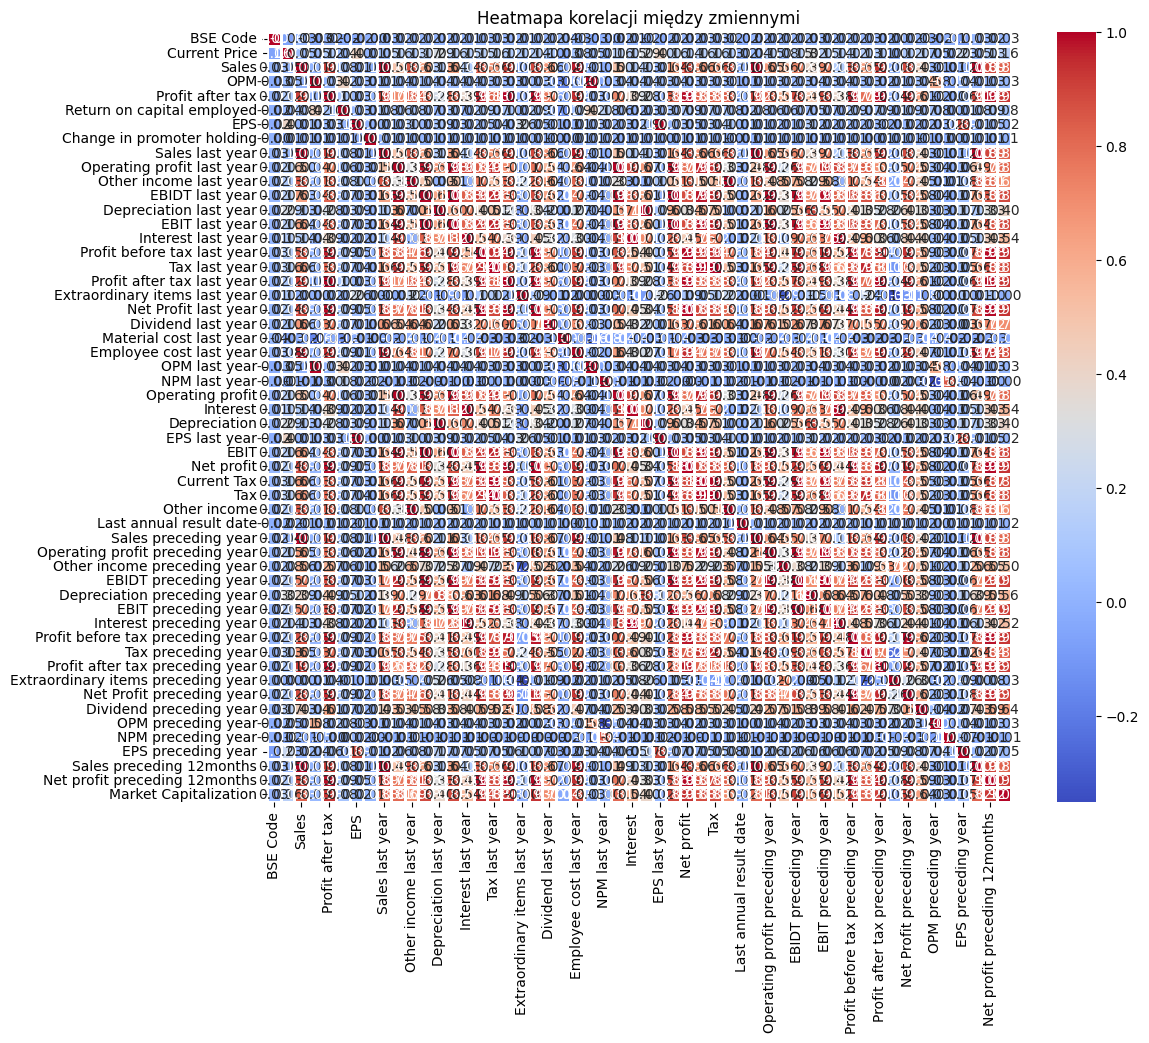

In [10]:
corr = df_fi.corr(numeric_only=True)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=2)
plt.title("Heatmapa korelacji między zmiennymi")
plt.show()